In [1]:
import pandas as pd
import numpy as np

In [2]:
# prompt: give code to connect with google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
amazon_food_data = pd.read_csv('/content/drive/My Drive/Amazon-Food-Reviews.csv')

In [4]:
amazon_food_data.head()

,Score,Summary,Text
0,1,"Great product, terrible price",Do not buy at this price! There are a dozen r...
1,1,Not impressed at ALL,"This product was not HORRIBLE, but I feel chea..."
2,1,Don't order from Amazon!,My dog loves this food and when I saw it here ...
3,1,"Maybe good cracker, but package was damaged","This may be a good cracker, but I had to retur..."
4,1,"Great rice, price is such a rip-off","It is a great product, however, who would spen..."


In [5]:
# Convert Score to Positive (4, 5) and Negative (1, 2, 3)
amazon_food_data['Sentiment'] = amazon_food_data['Score'].apply(lambda x: 'Positive' if x > 3 else 'Negative')

# Display the first few rows to verify the changes
print(amazon_food_data.head())

   Score                                      Summary  \
0      1                Great product, terrible price   
1      1                         Not impressed at ALL   
2      1                     Don't order from Amazon!   
3      1  Maybe good cracker, but package was damaged   
4      1          Great rice, price is such a rip-off   

                                                Text Sentiment  
0  Do not buy at this price!  There are a dozen r...  Negative  
1  This product was not HORRIBLE, but I feel chea...  Negative  
2  My dog loves this food and when I saw it here ...  Negative  
3  This may be a good cracker, but I had to retur...  Negative  
4  It is a great product, however, who would spen...  Negative  


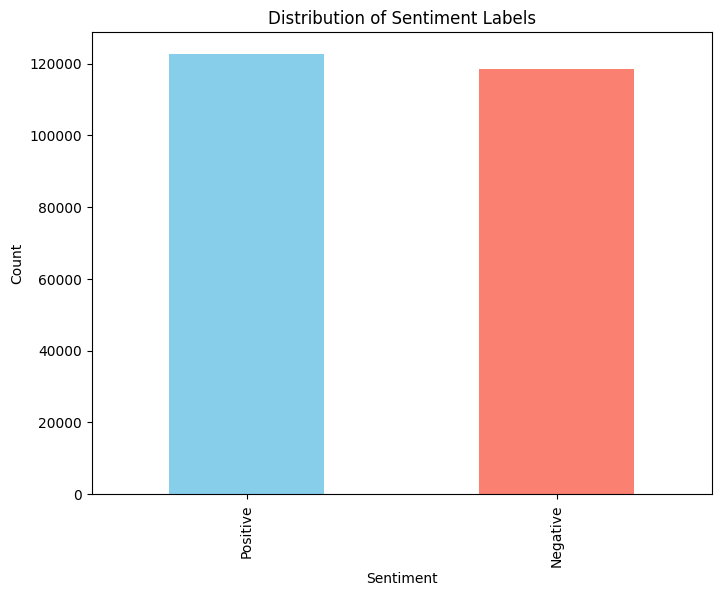

In [6]:
import matplotlib.pyplot as amazon_food_plt
# Plot distribution of Positive and Negative labels
sentiment_counts = amazon_food_data['Sentiment'].value_counts()
amazon_food_plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'salmon'])
amazon_food_plt.title('Distribution of Sentiment Labels')
amazon_food_plt.xlabel('Sentiment')
amazon_food_plt.ylabel('Count')
amazon_food_plt.show()

In [ ]:
sentiment_counts

,count
Sentiment,
Positive,122628
Negative,118443


In [7]:
# Balance the dataset to have 7500 samples for each class
positive_samples = amazon_food_data[amazon_food_data['Sentiment'] == 'Positive'].sample(n=7500)
negative_samples = amazon_food_data[amazon_food_data['Sentiment'] == 'Negative'].sample(n=7500)

# Combine balanced data
balanced_data = pd.concat([positive_samples, negative_samples]).reset_index(drop=True)

# Verify the balanced dataset
print(balanced_data['Sentiment'].value_counts())


Sentiment
Positive    7500
Negative    7500
Name: count, dtype: int64


In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK stopwords if not already downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Define preprocessing function
def preprocess_text(text):
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove words with 2 or fewer characters
    text = ' '.join([word for word in text.split() if len(word) > 2])
    return text

# Apply the preprocessing function to the Text column
balanced_data['Processed_Text'] = balanced_data['Text'].apply(preprocess_text)

# Display the first few rows to verify
print(balanced_data[['Text', 'Processed_Text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                Text  \
0  This is the same seasoning that the threater p...   
1  I am usually a non flavored coffee drinker, bu...   
2  This is a great product.  Tastes wonderful on ...   
3  We chose a Thing 1/Thing 2 theme for our twins...   
4  I can taste the sugar substitute in this quite...   

                                      Processed_Text  
0  this the same seasoning that the threater puts...  
1  usually non flavored coffee drinker but like m...  
2  this great product tastes wonderful steak prim...  
3  chose thing 1thing theme for our twins first b...  
4  can taste the sugar substitute this quite stro...  


In [ ]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'r

In [ ]:
balanced_data[['Text', 'Processed_Text']].head()

,Text,Processed_Text
0,I've found that Onion Sprouts are one of the f...,ive found that onion sprouts are one the fussi...
1,We bought this for our extreme chewer abotu 6 ...,bought this for our extreme chewer abotu month...
2,Great offer- bulk dog treats for a decent pric...,great offer bulk dog treats for decent price o...
3,My husband absolutely loves these. He's self-...,husband absolutely loves these hes selfemploye...
4,"Looked all over the web for these, and even we...",looked all over the web for these and even wen...


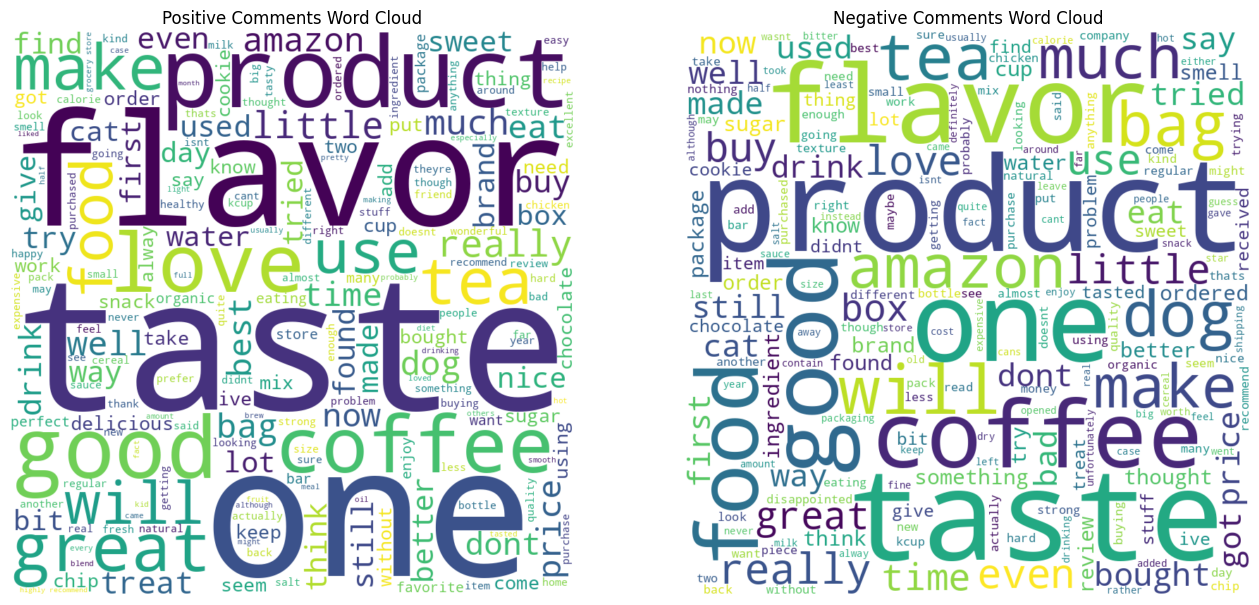

In [ ]:
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Separate positive and negative comments
positive_comments = " ".join(balanced_data[balanced_data['Sentiment'] == 'Positive']['Processed_Text'])
negative_comments = " ".join(balanced_data[balanced_data['Sentiment'] == 'Negative']['Processed_Text'])


# Generate word cloud for positive comments
wordcloud_positive = WordCloud(width=800, height=800, background_color="white",
                               contour_width=1).generate(positive_comments)

# Generate word cloud for negative comments
wordcloud_negative = WordCloud(width=800, height=800, background_color="white",
                               contour_width=1).generate(negative_comments)

# Plot the word clouds side by side
plt.figure(figsize=(16, 8))

# Display positive word cloud
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.title("Positive Comments Word Cloud")
plt.axis("off")

# Display negative word cloud
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.title("Negative Comments Word Cloud")
plt.axis("off")

plt.show()


In [9]:
# Initialize the Porter stemmer
stemmer = PorterStemmer()

# Define function to remove stop words and apply stemming
def remove_stopwords_and_stem(text):
    # Remove stop words and apply stemming
    words = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return ' '.join(words)

# Apply the function to the Processed_Text column
balanced_data['Processed_Text'] = balanced_data['Processed_Text'].apply(remove_stopwords_and_stem)

# Display the first few rows to verify
balanced_data[['Text', 'Processed_Text']].head()


,Text,Processed_Text
0,This is the same seasoning that the threater p...,season threater put popcorn use buy food marke...
1,"I am usually a non flavored coffee drinker, bu...",usual non flavor coffe drinker like mix thing ...
2,This is a great product. Tastes wonderful on ...,great product tast wonder steak prime rib chic...
3,We chose a Thing 1/Thing 2 theme for our twins...,chose thing 1thing theme twin first birthday p...
4,I can taste the sugar substitute in this quite...,tast sugar substitut quit strongli enough disg...


In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Parameters
max_words = 5000  # Vocabulary size
max_len = 100  # Maximum sequence length

# Tokenize the text data
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(balanced_data['Processed_Text'])
X = tokenizer.texts_to_sequences(balanced_data['Processed_Text'])
X = pad_sequences(X, maxlen=max_len)

# Convert labels to binary
y = balanced_data['Sentiment'].apply(lambda x: 1 if x == 'Positive' else 0).values

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

# CNN Model
cnn_model = Sequential()
cnn_model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
cnn_model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
cnn_model.add(Dense(10, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the CNN model
history = cnn_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test)
print(f"CNN Accuracy: {cnn_accuracy:.4f}")


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.6414 - loss: 0.6185 - val_accuracy: 0.7910 - val_loss: 0.4501
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8621 - loss: 0.3373 - val_accuracy: 0.8010 - val_loss: 0.4423
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9475 - loss: 0.1704 - val_accuracy: 0.7947 - val_loss: 0.4964
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9886 - loss: 0.0603 - val_accuracy: 0.7947 - val_loss: 0.6262
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9983 - loss: 0.0152 - val_accuracy: 0.7907 - val_loss: 0.7520
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7910 - loss: 0.7515
CNN Accuracy: 0.7907


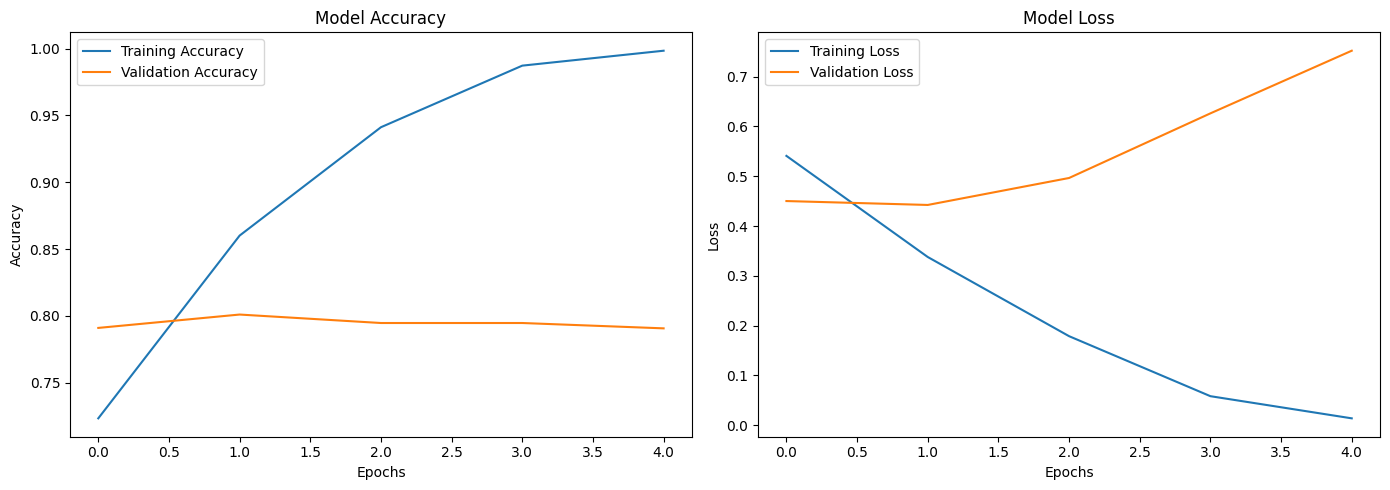

In [ ]:
# Plot accuracy and loss graphs
# Accuracy
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# RNN Model
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
rnn_model.add(LSTM(64, return_sequences=False))
rnn_model.add(Dense(10, activation='relu'))
rnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the RNN model and save the training history
history = rnn_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the RNN model
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test, y_test)
print(f"RNN Accuracy: {rnn_accuracy:.4f}")


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.6613 - loss: 0.6002 - val_accuracy: 0.7840 - val_loss: 0.4553
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.8410 - loss: 0.3667 - val_accuracy: 0.7833 - val_loss: 0.4895
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - accuracy: 0.8861 - loss: 0.2732 - val_accuracy: 0.7723 - val_loss: 0.5944
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9196 - loss: 0.2085 - val_accuracy: 0.7820 - val_loss: 0.5665
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 48s 109ms/step - accuracy: 0.9371 - loss: 0.1594 - val_accuracy: 0.7660 - val_loss: 0.7072
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7632 - loss: 0.6965
RNN Accuracy: 0.7660


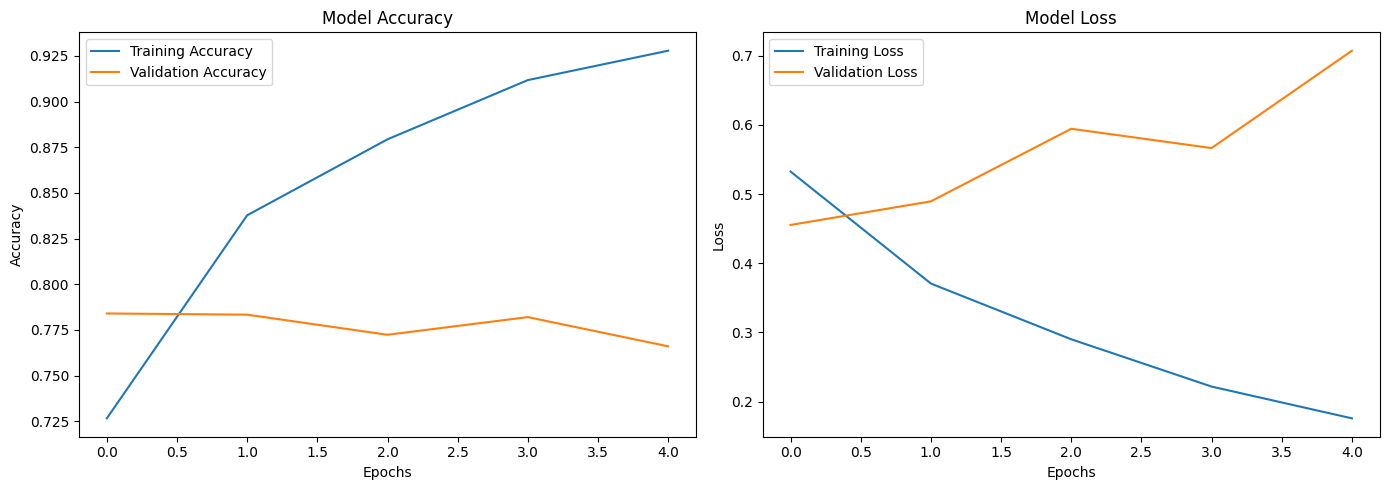

In [ ]:

# Plot accuracy and loss graphs
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
